### 0. So sánh mBERT và PhoBERT cho Phân loại Cảm xúc tiếng Việt

### Mục tiêu
Mục tiêu của notebook này là tinh chỉnh và so sánh hiệu năng của hai kiến ​​trúc dựa trên transformer phổ biến—**mBERT (BERT đa ngôn ngữ)** và **PhoBERT (BERT dành riêng cho tiếng Việt)**—trên tập dữ liệu **UIT-VSFC (Corpus phản hồi của sinh viên Việt Nam)** để phân tích cảm xúc.

### Các bước chính
1. **Khám phá dữ liệu:** Tải và kiểm tra cấu trúc tập dữ liệu UIT-VSFC.

2. **Phân tích mã hóa từ:** So sánh cách mBERT và PhoBERT (với ViTokenizer) xử lý phân đoạn văn bản tiếng Việt.

3. **Huấn luyện mô hình:** Tinh chỉnh cả hai mô hình bằng cách sử dụng API `Trainer` của Hugging Face.

4. **Đánh giá :** So sánh các chỉ số hiệu năng (Accuracy, F1 score, Precision, Recall, Confusion Matrix) và

5. **Phân tích lỗi:** trực quan hóa các lỗi phân loại bằng Ma trận nhầm lẫn để hiểu điểm mạnh và điểm yếu của mô hình.

6. **Phân tích đặc điểm câu bị phân loại sai:** Tìm hiểu xem liệu độ dài của câu có ảnh hưởng đến khả năng dự đoán của mô hình hay không

## 1. Cài đặt và Chuẩn bị Môi trường

Phần này thực hiện cài đặt các thư viện cần thiết và thiết lập môi trường làm việc:
- `transformers`: Thư viện của Hugging Face để tải và huấn luyện các mô hình BERT, PhoBERT.
- `datasets`: Dùng để tải và xử lý tập dữ liệu UIT-VSFC.
- `pyvi`: Thư viện tách từ tiếng Việt (Word Segmentation), cần thiết cho tiền xử lý dữ liệu đầu vào của PhoBERT.
- `torch` & `scikit-learn`: Các thư viện hỗ trợ huấn luyện và đánh giá mô hình.

In [1]:
!pip install -q transformers datasets pyvi torch scikit-learn

In [21]:
from datasets import load_dataset
import pandas as pd
from transformers import AutoTokenizer
from pyvi import ViTokenizer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, ConfusionMatrixDisplay, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoModelForSequenceClassification
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch
import os
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Tải và Khám phá Dữ liệu

Tải tập dữ liệu **UIT-VSFC** (Vietnamese Students' Feedback Corpus) từ Hugging Face Hub. Đây là tập dữ liệu phổ biến cho bài toán phân tích cảm xúc tiếng Việt, bao gồm 3 tập con:
- **Train**: Dùng để huấn luyện mô hình (11,426 mẫu).
- **Validation**: Dùng để điều chỉnh tham số và đánh giá trong quá trình huấn luyện (1,584 mẫu).
- **Test**: Dùng để đánh giá cuối cùng độ chính xác của mô hình (3,166 mẫu).

In [3]:
dataset = load_dataset("ura-hcmut/UIT-VSFC")
print("/n--- Cấu trúc Dataset ---")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


/n--- Cấu trúc Dataset ---
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 11426
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1584
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3166
    })
})


In [4]:
print(dataset['train'].to_pandas().head())


                                                text     label
0                          slide giáo trình đầy đủ .  positive
1     nhiệt tình giảng dạy , gần gũi với sinh viên .  positive
2               đi học đầy đủ full điểm chuyên cần .  negative
3  chưa áp dụng công nghệ thông tin và các thiết ...  negative
4  thầy giảng bài hay , có nhiều bài tập ví dụ ng...  positive


## 3. So sánh Tokenization giữa mBERT và PhoBERT

So sánh hai phương pháp xử lý ngôn ngữ khác nhau:
- **mBERT (Multilingual BERT)**: Sử dụng thuật toán **WordPiece**, chia văn bản thành các đơn vị con (subwords) dựa trên ký tự. Điều này có thể khiến các từ ghép tiếng Việt bị chia nhỏ một cách rời rạc.
- **PhoBERT**: Được tối ưu riêng cho tiếng Việt, yêu cầu một bước **Tách từ (Word Segmentation)** bằng `ViTokenizer` trước khi đưa vào mô hình. Điều này giúp mô hình hiểu được các từ ghép (ví dụ: 'học_sinh' thay vì 'học' và 'sinh').

In [5]:
mbert_tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")
phobert_tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

In [6]:
def compare_tokenizers(sentence):
    print(f"\n--- Câu gốc: {sentence} ---")

    # Xử lý mBERT
    mbert_tokens = mbert_tokenizer.tokenize(sentence)
    print(f"mBERT tokens ({len(mbert_tokens)}): {mbert_tokens}")

    # Xử lý PhoBERT (Cần tách từ trước)
    segmented_sentence = ViTokenizer.tokenize(sentence)
    print(f"Sau khi tách từ (cho PhoBERT): {segmented_sentence}")
    phobert_tokens = phobert_tokenizer.tokenize(segmented_sentence)
    print(f"PhoBERT tokens ({len(phobert_tokens)}): {phobert_tokens}")

In [45]:
print("\n--- Selecting additional sentences for tokenization comparison ---")
sample_sentences = [
    dataset['test']['text'][10], # Example with potentially complex review
    dataset['test']['text'][25], # Another diverse example
    dataset['test']['text'][50]  # A third unique example
]

for i, sentence in enumerate(sample_sentences):
    print(f"Câu {i+1}: {sentence}")


--- Selecting additional sentences for tokenization comparison ---
Câu 1: giảng viên nhiệt tình trong công tác giảng dạy .
Câu 2: em học bên chất lượng cao mà phòng máy không cung cấp đủ máy ( vì máy hư hoặc không cài chương trình ) .
Câu 3: không biết được chính xác bao giờ học thật để đi học .


In [46]:
for i, sentence in enumerate(sample_sentences):
    print(f"\n--- Tokenization for Câu {i+1}: --- ")
    compare_tokenizers(sentence)


--- Tokenization for Câu 1: --- 

--- Câu gốc: giảng viên nhiệt tình trong công tác giảng dạy . ---
mBERT tokens (10): ['giảng', 'viên', 'nhiệt', 'tình', 'trong', 'công', 'tác', 'giảng', 'dạy', '.']
Sau khi tách từ (cho PhoBERT): giảng_viên nhiệt_tình trong công_tác giảng_dạy .
PhoBERT tokens (6): ['giảng_viên', 'nhiệt_tình', 'trong', 'công_tác', 'giảng_dạy', '.']

--- Tokenization for Câu 2: --- 

--- Câu gốc: em học bên chất lượng cao mà phòng máy không cung cấp đủ máy ( vì máy hư hoặc không cài chương trình ) . ---
mBERT tokens (27): ['em', 'học', 'bên', 'chất', 'lượng', 'cao', 'mà', 'phòng', 'máy', 'không', 'cung', 'cấp', 'đủ', 'máy', '(', 'vì', 'máy', 'h', '##ư', 'hoặc', 'không', 'c', '##ài', 'chương', 'trình', ')', '.']
Sau khi tách từ (cho PhoBERT): em học bên chất_lượng cao mà phòng máy không cung_cấp đủ máy ( vì máy hư hoặc không cài chương_trình ) .
PhoBERT tokens (22): ['em', 'học', 'bên', 'chất_lượng', 'cao', 'mà', 'phòng', 'máy', 'không', 'cung_cấp', 'đủ', 'máy', '(', 'vì

## 4. Tiền xử lý dữ liệu và Định dạng Tensor

Thực hiện các bước chuẩn bị dữ liệu quan trọng để đưa vào huấn luyện mô hình:
- **Ánh xạ nhãn (Label Mapping):** Chuyển đổi các nhãn văn bản ('positive', 'neutral', 'negative') sang các ID số tương ứng.
- **Tokenization:** Áp dụng các hàm mã hóa riêng biệt cho mBERT và PhoBERT để xử lý văn bản thành các vector số.
- **Lọc dữ liệu:** Loại bỏ các mẫu dữ liệu rỗng hoặc không hợp lệ để đảm bảo chất lượng tập huấn luyện.
- **Định dạng Tensor:** Chuyển đổi tập dữ liệu sang định dạng PyTorch tensor, sẵn sàng cho việc huấn luyện với Hugging Face Trainer.

In [8]:
label2id = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

In [9]:
# Hàm 1: Chuyển đổi label (Phiên bản nâng cấp an toàn)
def encode_labels(example):
    # Ép kiểu nhãn về dạng chuỗi (thành "None" nếu bị rỗng), sau đó chuyển thành chữ thường và xóa khoảng trắng
    safe_label = str(example['label']).strip().lower()

    # Dùng hàm .get() để tìm ID. Nếu safe_label không có trong label2id, mặc định gán là 1 (neutral/none)
    example['labels'] = label2id.get(safe_label, 1)
    return example

# Hàm 2: Tokenize cho mBERT (Trực tiếp)
def tokenize_mbert(examples):
    return mbert_tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128 # Giới hạn độ dài câu, bạn có thể tăng lên 256 nếu câu dài
    )

# Hàm 3: Tokenize cho PhoBERT (Phải tách từ trước)
def tokenize_phobert(examples):
    # Tách từ (Word Segment) cho toàn bộ batch
    segmented_texts = [ViTokenizer.tokenize(text) for text in examples['text']]
    return phobert_tokenizer(
        segmented_texts,
        padding='max_length',
        truncation=True,
        max_length=128
    )


In [10]:
# Bước A: Mã hóa labels cho dataset gốc
dataset = dataset.map(encode_labels)
dataset = dataset.filter(lambda example: example['text'] is not None and isinstance(example['text'], str) and len(example['text'].strip()) > 0)

# Bước B: Tạo 2 phiên bản dataset đã được tokenize cho 2 model
# 1. Dataset cho mBERT
mbert_dataset = dataset.map(tokenize_mbert, batched=True)

# 2. Dataset cho PhoBERT
phobert_dataset = dataset.map(tokenize_phobert, batched=True)

# Cần set format sang PyTorch tensor để train
mbert_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
phobert_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

print("Hoàn tất! Cấu trúc dữ liệu mBERT:", mbert_dataset['train'].column_names)
print("Cấu trúc dữ liệu PhoBERT:", phobert_dataset['train'].column_names)

Map:   0%|          | 0/1583 [00:00<?, ? examples/s]

Hoàn tất! Cấu trúc dữ liệu mBERT: ['text', 'label', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']
Cấu trúc dữ liệu PhoBERT: ['text', 'label', 'labels', 'input_ids', 'attention_mask']


### 5. Định nghĩa các chỉ số đánh giá (Metrics)

Hàm `compute_metrics` được sử dụng để tính toán hiệu năng của mô hình sau mỗi epoch huấn luyện. Các chỉ số bao gồm:

- **Accuracy (Độ chính xác)**: Tỷ lệ các dự đoán đúng trên tổng số mẫu.
- **Macro F1-score**: Trung bình cộng điểm F1 của từng lớp, giúp đánh giá khách quan khi tập dữ liệu có sự chênh lệch về số lượng giữa các nhãn.
- **Precision (Độ chính xác dự đoán)**: Khả năng mô hình dự đoán đúng các mẫu thuộc một lớp cụ thể.
- **Recall (Độ nhạy)**: Khả năng mô hình tìm thấy tất cả các mẫu thực sự thuộc về một lớp.

In [16]:
def compute_metrics(eval_pred):
    # Lấy ra dự đoán (predictions) và nhãn thực tế (labels)
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Tính Accuracy và Macro F1
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro')
    precision = precision_score(labels, predictions, average='macro', zero_division=0)
    recall = recall_score(labels, predictions, average='macro', zero_division=0)

    return {
        'accuracy': acc,
        'f1_macro': f1,
        'precision_macro': precision,
        'recall_macro': recall
    }

## 6. Khởi tạo Mô hình và Cấu hình Huấn luyện

Thực hiện các bước chuẩn bị cuối cùng trước khi huấn luyện:
- **Khởi tạo kiến trúc mô hình:** Tải các trọng số áp chót của `bert-base-multilingual-cased` (mBERT) và `vinai/phobert-base` (PhoBERT) với số lượng nhãn đầu ra là 3 (Tiêu cực, Trung lập, Tích cực).
- **Thiết lập tham số huấn luyện:** Định nghĩa `TrainingArguments` để kiểm soát các siêu tham số như tốc độ học (learning rate), số epoch, và kích thước batch.
- **Cấu hình Trainer:** Sử dụng API `Trainer` của Hugging Face để đóng gói mô hình, dữ liệu đã tokenize và các chỉ số đánh giá, giúp quá trình huấn luyện và đánh giá diễn ra nhất quán cho cả hai mô hình.

In [12]:

# Số lượng nhãn (Negative, Neutral, Positive)
NUM_LABELS = 3

print("Đang tải kiến trúc mBERT...")
mbert_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-multilingual-cased",
    num_labels=NUM_LABELS
)

print("Đang tải kiến trúc PhoBERT...")
phobert_model = AutoModelForSequenceClassification.from_pretrained(
    "vinai/phobert-base",
    num_labels=NUM_LABELS
)

Đang tải kiến trúc mBERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Đang tải kiến trúc PhoBERT...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.bias            | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initia

In [13]:
training_args = TrainingArguments(
    output_dir='/content/drive/MyDrive/NLP/results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir='/content/drive/MyDrive/NLP/logs',
    logging_steps=50,
    seed=42
)

# 1. Khởi tạo Trainer cho mBERT
mbert_trainer = Trainer(
    model=mbert_model,
    args=training_args,
    train_dataset=mbert_dataset['train'],
    eval_dataset=mbert_dataset['validation'],
    compute_metrics=compute_metrics
)

# 2. Khởi tạo Trainer cho PhoBERT
phobert_trainer = Trainer(
    model=phobert_model,
    args=training_args,
    train_dataset=phobert_dataset['train'],
    eval_dataset=phobert_dataset['validation'],
    compute_metrics=compute_metrics
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [14]:
print("--- BẮT ĐẦU HUẤN LUYỆN mBERT ---")
mbert_trainer.train()

--- BẮT ĐẦU HUẤN LUYỆN mBERT ---


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.270709,0.268405,0.928617,0.803276
2,0.222492,0.242967,0.935565,0.810595
3,0.136710,0.273750,0.934302,0.808399


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2145, training_loss=0.22166465390256512, metrics={'train_runtime': 900.6402, 'train_samples_per_second': 38.06, 'train_steps_per_second': 2.382, 'total_flos': 2254750433220096.0, 'train_loss': 0.22166465390256512, 'epoch': 3.0})

## 7. Huấn luyện và Đánh giá Mô hình

Trong phần này, chúng ta sẽ thực hiện quá trình tinh chỉnh (fine-tuning) cho cả hai mô hình mBERT và PhoBERT trên tập dữ liệu UIT-VSFC. Quá trình này giúp mô hình học cách phân loại cảm xúc dựa trên đặc thù ngôn ngữ của sinh viên Việt Nam.

Sau khi hoàn tất huấn luyện, chúng ta sẽ tiến hành đánh giá mô hình trên tập dữ liệu kiểm tra (test set). Kết quả đánh giá sẽ dựa trên các chỉ số hiệu năng quan trọng như:
- **Accuracy**
- **Precision**
- **Recall**
- **Macro F1-score**
- **Confusion Matrix**

Việc so sánh các chỉ số này giữa mBERT và PhoBERT sẽ giúp chúng ta xác định kiến trúc nào hiệu quả hơn cho bài toán phân tích cảm xúc tiếng Việt.

In [15]:
print("--- BẮT ĐẦU HUẤN LUYỆN PhoBERT ---")
phobert_trainer.train()

--- BẮT ĐẦU HUẤN LUYỆN PhoBERT ---


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.172035,0.206035,0.950095,0.844713
2,0.168804,0.200572,0.950726,0.857781
3,0.121958,0.220348,0.955148,0.858260


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2145, training_loss=0.18303590432191508, metrics={'train_runtime': 847.5309, 'train_samples_per_second': 40.445, 'train_steps_per_second': 2.531, 'total_flos': 2254750433220096.0, 'train_loss': 0.18303590432191508, 'epoch': 3.0})

In [24]:
print("--- Đánh giá mBERT trên tập test ---")
mbert_results = mbert_trainer.evaluate(mbert_dataset['test'])
print(mbert_results)

print("\n--- Đánh giá PhoBERT trên tập test ---")
phobert_results = phobert_trainer.evaluate(phobert_dataset['test'])
print(phobert_results)

--- Đánh giá mBERT trên tập test ---


{'eval_loss': 0.33377528190612793, 'eval_accuracy': 0.9245104232469994, 'eval_f1_macro': 0.7952079575741594, 'eval_runtime': 27.4303, 'eval_samples_per_second': 115.42, 'eval_steps_per_second': 7.218, 'epoch': 3.0}

--- Đánh giá PhoBERT trên tập test ---


{'eval_loss': 0.28668662905693054, 'eval_accuracy': 0.9412507896399241, 'eval_f1_macro': 0.8346420517152224, 'eval_runtime': 23.271, 'eval_samples_per_second': 136.049, 'eval_steps_per_second': 8.508, 'epoch': 3.0}


Đang tạo Confusion Matrix cho mBERT...


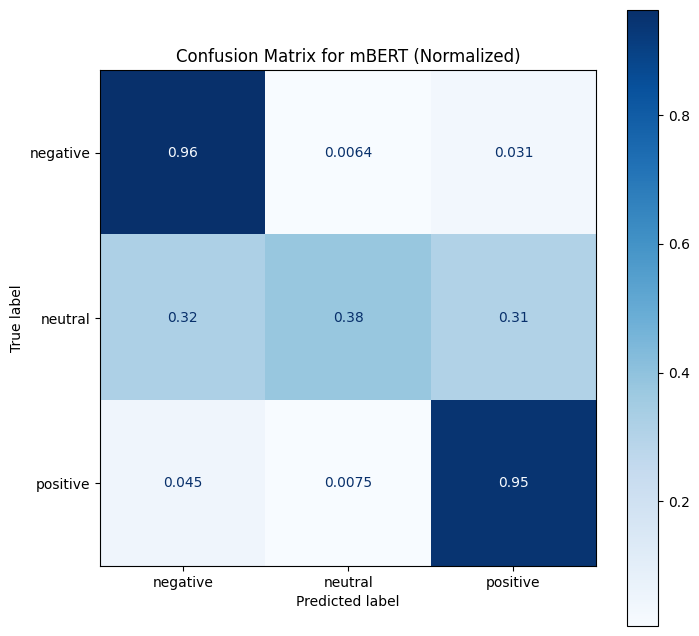

In [19]:

# --- Confusion Matrix cho mBERT ---
print("Đang tạo Confusion Matrix cho mBERT...")
mbert_predictions = mbert_trainer.predict(mbert_dataset['test'])
mbert_predicted_labels = np.argmax(mbert_predictions.predictions, axis=-1)
mbert_true_labels = mbert_dataset['test']['labels']

fig_mbert, ax_mbert = plt.subplots(figsize=(8, 8))
display_mbert = ConfusionMatrixDisplay.from_predictions(
    mbert_true_labels,
    mbert_predicted_labels,
    display_labels=['negative', 'neutral', 'positive'],
    cmap=plt.cm.Blues,
    normalize='true', # Normalize to show percentages
    ax=ax_mbert
)
ax_mbert.set_title('Confusion Matrix for mBERT (Normalized)')
plt.show()




Đang tạo Confusion Matrix cho PhoBERT...


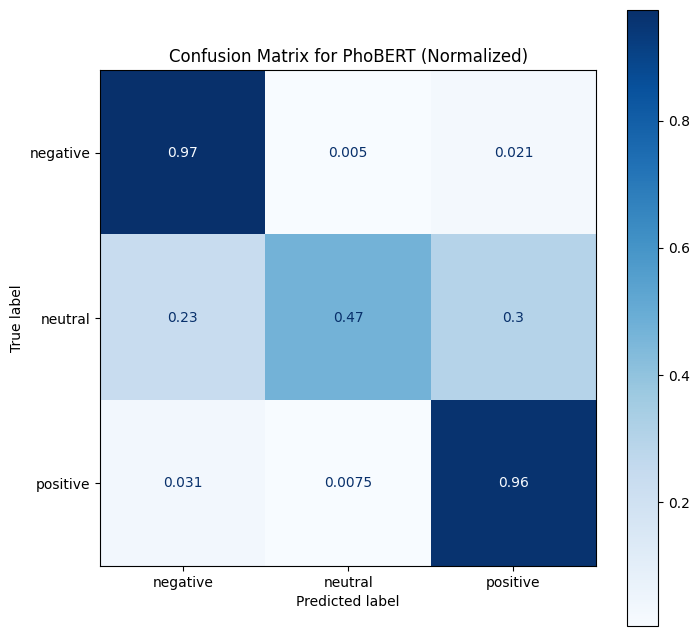

In [20]:
# --- Confusion Matrix cho PhoBERT ---
print("\nĐang tạo Confusion Matrix cho PhoBERT...")
phobert_predictions = phobert_trainer.predict(phobert_dataset['test'])
phobert_predicted_labels = np.argmax(phobert_predictions.predictions, axis=-1)
phobert_true_labels = phobert_dataset['test']['labels']

fig_phobert, ax_phobert = plt.subplots(figsize=(8, 8))
display_phobert = ConfusionMatrixDisplay.from_predictions(
    phobert_true_labels,
    phobert_predicted_labels,
    display_labels=['negative', 'neutral', 'positive'],
    cmap=plt.cm.Blues,
    normalize='true',
    ax=ax_phobert
)
ax_phobert.set_title('Confusion Matrix for PhoBERT (Normalized)')
plt.show()

## 8. Phân tích lỗi (Error Analysis)

Sau khi đánh giá bằng các chỉ số định lượng, bước này giúp chúng ta đi sâu vào phân tích định tính để hiểu rõ bản chất các lỗi mà mô hình gặp phải:

1.  **Trích xuất các dự đoán sai**: Lọc ra những câu trong tập kiểm tra (`test set`) mà nhãn dự đoán của mô hình không khớp với nhãn thực tế.
2.  **So sánh mBERT vs PhoBERT**: Lưu trữ các mẫu lỗi vào DataFrame riêng biệt cho từng mô hình để dễ dàng truy vấn.
3.  **Kiểm tra trực quan**: Hiển thị ngẫu nhiên các mẫu lỗi để nhận diện các đặc điểm chung (ví dụ: câu quá ngắn, câu chứa từ lóng, hoặc các trường hợp nhãn 'neutral' dễ gây tranh cãi).
4.  **Thống kê loại lỗi**: Đếm số lượng lỗi theo từng cặp (Nhãn thật - Nhãn dự đoán) để xác định xu hướng nhầm lẫn chính của mô hình.

In [37]:
id2label = {v: k for k, v in label2id.items()}

def print_random_misclassified(
    df_misclassified, id2label, model_name, num_samples=5
):
    """In một vài ví dụ bị phân loại sai ngẫu nhiên."""
    if not df_misclassified.empty:
        print(f"\n--- Ví dụ bị phân loại sai ngẫu nhiên cho {model_name} ---")
        random_samples = df_misclassified.sample(min(num_samples, len(df_misclassified)))
        for i, row in random_samples.iterrows():
            print(f"  Văn bản: {row['text']}")
            print(f"  Nhãn thực tế: {row['true_label']}")
            print(f"  Nhãn dự đoán: {row['predicted_label']}")
            print("-" * 30)
    else:
        print(f"\nKhông có mẫu bị phân loại sai nào để hiển thị cho {model_name}.")


# Lấy văn bản từ tập test và chuyển thành list
mbert_texts = list(dataset['test']['text'])
phobert_texts = list(dataset['test']['text'])

def get_misclassified_df(true_labels, predicted_labels, texts, id2label):
    # Chuyển true_labels sang numpy array để so sánh và đảm bảo là 1D array
    # Dù set_format đã đặt type='torch', khi truy cập ['labels'], nó vẫn có thể là datasets.arrow_dataset.Column
    # Do đó, cần chuyển sang numpy array một cách rõ ràng trước khi squeeze.
    if isinstance(true_labels, torch.Tensor):
        true_labels_np = true_labels.cpu().numpy().squeeze()
    else:
        # Nếu không phải torch.Tensor (ví dụ Column), chuyển đổi trực tiếp sang numpy array.
        true_labels_np = np.array(true_labels).squeeze()

    # predicted_labels cũng nên đảm bảo là 1D array
    predicted_labels_np = predicted_labels.squeeze()

    misclassified_indices = np.flatnonzero(true_labels_np != predicted_labels_np) # Sử dụng np.flatnonzero
    misclassified_data = []

    for idx in misclassified_indices:
        # Chuyển numpy.int64 sang int Python thông thường trước khi sử dụng làm chỉ mục
        misclassified_data.append(
            {
                "text": texts[int(idx)], # Chuyển idx sang int
                "true_label": id2label[true_labels_np[idx]],
                "predicted_label": id2label[predicted_labels_np[idx]],
            }
        )
    return pd.DataFrame(misclassified_data)

# Tạo các DataFrame chứa các mẫu bị phân loại sai
df_mbert_misclassified = get_misclassified_df(
    mbert_dataset['test']['labels'], mbert_predicted_labels, mbert_texts, id2label
)
df_phobert_misclassified = get_misclassified_df(
    phobert_dataset['test']['labels'], phobert_predicted_labels, phobert_texts, id2label
)

# --- Hiển thị ví dụ bị phân loại sai cho mBERT ---
print_random_misclassified(df_mbert_misclassified, id2label, "mBERT", num_samples=20)

# --- Hiển thị ví dụ bị phân loại sai cho PhoBERT ---
print_random_misclassified(df_phobert_misclassified, id2label, "PhoBERT", num_samples=20)


--- Ví dụ bị phân loại sai ngẫu nhiên cho mBERT ---
  Văn bản: có kết hợp với bài tập ví dụ .
  Nhãn thực tế: neutral
  Nhãn dự đoán: positive
------------------------------
  Văn bản: như vậy tụi em sẽ định hướng tốt hơn và tập trung vào những thứ cần thiết .
  Nhãn thực tế: neutral
  Nhãn dự đoán: negative
------------------------------
  Văn bản: đối với cô wzjwz32 , cô rất tận tình , giải đáp thắc mắc và hướng đến sinh viên cùng trao đổi đối với y , hoàn toàn tách biệt với sinh viên , không có hướng trao đổi mà là hướng tra khảo kiến thức sinh viên .
  Nhãn thực tế: neutral
  Nhãn dự đoán: positive
------------------------------
  Văn bản: thầy dạy ổn ạ .
  Nhãn thực tế: neutral
  Nhãn dự đoán: positive
------------------------------
  Văn bản: slide bài giảng chưa được đưa lên .
  Nhãn thực tế: positive
  Nhãn dự đoán: negative
------------------------------
  Văn bản: bổ sung nhiều bài tập , hướng dẫn thảo luận tại lớp .
  Nhãn thực tế: negative
  Nhãn dự đoán: positive
--------

In [39]:
# --- Đếm số lượng lỗi theo loại cho mBERT ---
print("\n--- Số lượng lỗi theo loại cho mBERT ---")
m_bert_error_counts = df_mbert_misclassified.groupby(['true_label', 'predicted_label']).size().reset_index(name='count')
print(m_bert_error_counts)

# --- Đếm số lượng lỗi theo loại cho PhoBERT ---
print("\n--- Số lượng lỗi theo loại cho PhoBERT ---")
phobert_error_counts = df_phobert_misclassified.groupby(['true_label', 'predicted_label']).size().reset_index(name='count')
print(phobert_error_counts)


--- Số lượng lỗi theo loại cho mBERT ---
  true_label predicted_label  count
0   negative         neutral      9
1   negative        positive     43
2    neutral        negative     53
3    neutral        positive     51
4   positive        negative     71
5   positive         neutral     12

--- Số lượng lỗi theo loại cho PhoBERT ---
  true_label predicted_label  count
0   negative         neutral      7
1   negative        positive     29
2    neutral        negative     39
3    neutral        positive     50
4   positive        negative     49
5   positive         neutral     12


In [40]:
mbert_misclassified_count = len(df_mbert_misclassified)
phobert_misclassified_count = len(df_phobert_misclassified)

print(f"Model\tMisclassified")
print(f"mBERT\t{mbert_misclassified_count}")
print(f"PhoBERT\t{phobert_misclassified_count}")

Model	Misclassified
mBERT	239
PhoBERT	186


### 9. Phân tích đặc điểm câu bị phân loại sai

Để tìm hiểu xem liệu độ dài của câu có ảnh hưởng đến khả năng dự đoán của mô hình hay không, chúng ta thực hiện các bước:
- Tính toán độ dài (số lượng ký tự) của tất cả các mẫu bị phân loại sai.
- Chuẩn bị dữ liệu để trực quan hóa sự khác biệt giữa mBERT và PhoBERT trong các phân đoạn độ dài khác nhau.

In [42]:
df_phobert_misclassified["length"] = df_phobert_misclassified["text"].apply(len)
print(df_phobert_misclassified.head())

                                                text true_label  \
0                       tính điểm thi đua các nhóm .   positive   
1  trong trường macbook thầy số hai thì không có ...   positive   
2  môn học này giúp chúng em hiểu ra những vấn đề...    neutral   
3             phần lớn chỉ là lý thuyết và bài tập .   positive   
4  như vậy tụi em sẽ định hướng tốt hơn và tập tr...    neutral   

  predicted_label  length  
0         neutral      28  
1        negative      62  
2        positive      55  
3        negative      38  
4        negative      75  


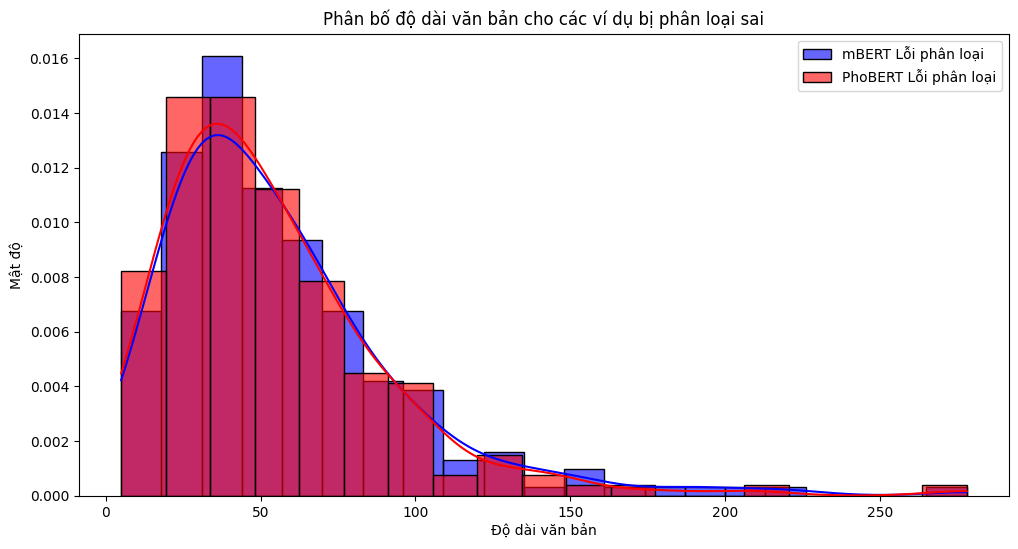

In [44]:
plt.figure(figsize=(12, 6))
sns.histplot(df_mbert_misclassified['length'], color='blue', label='mBERT Lỗi phân loại', kde=True, stat='density', alpha=0.6)
sns.histplot(df_phobert_misclassified['length'], color='red', label='PhoBERT Lỗi phân loại', kde=True, stat='density', alpha=0.6)
plt.title('Phân bố độ dài văn bản cho các ví dụ bị phân loại sai')
plt.xlabel('Độ dài văn bản')
plt.ylabel('Mật độ')
plt.legend()
plt.show()